# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
# 1) Imports básicos
import numpy as np
import pandas as pd

# Para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para estadísticas y correlaciones
from scipy import stats


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv("novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
print(df.head())

  id_cliente  edad  nivel_ingreso  visitas_mes  compras_mes  \
0  CL-100000  44.0       28565.77            9            1   
1  CL-100001  36.0       29673.44           11            3   
2  CL-100002  46.0       30642.95            9            0   
3  CL-100003  56.0       39468.61            8            0   
4  CL-100004  35.0       22527.83            9            2   

   gasto_publicidad_dirigida  satisfaccion  miembro_premium  abandono  \
0                      31.36           3.9                0         0   
1                      24.66           3.7                0         0   
2                       0.00           2.9                0         0   
3                       6.81           3.1                0         0   
4                      26.49           2.3                0         0   

  tipo_dispositivo region  ingreso_anual  
0            móvil  norte          23.22  
1           tablet    sur          93.47  
2            móvil   este           0.00  
3         

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `miembro_premium`
- `abandono`
- `ingreso_anual`

**Observaciones:**

- La edad presenta valores coherentes (ej. 35 a 56 años en los primeros registros).
- El nivel de ingreso varía entre usuarios, lo que sugiere diversidad económica.
- Se observa que los usuarios realizan varias visitas mensuales, pero no siempre realizan compras (ej. casos con 0 compras).
- El gasto en publicidad dirigida varía considerablemente entre usuarios, incluso con valores en 0.
- La variable `satisfaccion` se encuentra en una escala de aproximadamente 1 a 5.
- La variable `ingreso_anual` presenta valores desde 0, lo que indica que algunos usuarios no generan ingresos.


**Variables binarias**  
Las siguientes columnas representan variables binarias:

- `miembro_premium`
- `abandono`

**Observaciones:**

- Están codificadas como 0 y 1, por lo que **no requieren transformación adicional**.
- En los primeros registros, los usuarios no son premium ni han abandonado, aunque se requiere analizar todo el dataset para confirmar patrones.


**Variables categóricas**  
Se identifican las siguientes columnas categóricas:

- `id_cliente`
- `tipo_dispositivo`
- `region`

**Observaciones:**

- `id_cliente` funciona como identificador único.
- Se observan diferentes tipos de dispositivo como móvil y tablet.
- Existen distintas regiones como norte, sur y este.

---

### Conclusión de la exploración

- La estructura del dataset es clara y consistente.
- Los tipos de variables están bien definidos.
- No se observan problemas evidentes en los primeros registros.

Sin embargo, se requiere un análisis más profundo (por ejemplo, con estadísticas descriptivas) para confirmar patrones y detectar posibles anomalías en todo el conjunto de datos.


In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Seleccionar SOLO las variables numéricas relevantes
columnas_numericas = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'miembro_premium',
    'abandono',
    'ingreso_anual'
]

df_num = df[columnas_numericas]

# Estadísticas descriptivas con percentiles adicionales
estadisticas = df_num.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2)

# Mostrar resultado
print(estadisticas)


           edad  nivel_ingreso  visitas_mes  compras_mes  \
count  15000.00       15000.00     15000.00     15000.00   
mean      38.26       30019.70        10.03         1.21   
std       11.49        9833.17         3.16         1.11   
min       18.00        8000.00         1.00         0.00   
10%       23.00       17284.41         6.00         0.00   
25%       30.00       23127.10         8.00         0.00   
50%       38.00       30023.74        10.00         1.00   
75%       46.00       36768.44        12.00         2.00   
90%       53.00       42767.23        14.00         3.00   
max       75.00       74790.84        25.00         8.00   

       gasto_publicidad_dirigida  satisfaccion  miembro_premium  abandono  \
count                   15000.00      15000.00         15000.00  15000.00   
mean                       20.15          3.60             0.14      0.15   
std                        10.88          0.69             0.35      0.36   
min                         0.0

**Diagnóstico inicial de variables numéricas**

**edad**  
La edad presenta una distribución bastante equilibrada, con media y mediana cercanas (≈38 años), lo que sugiere una distribución aproximadamente simétrica sin sesgos importantes.

**nivel_ingreso**  
El nivel de ingreso muestra alta dispersión (std ≈ 9,833) y un rango amplio (8,000 a 74,790), lo que indica una base de clientes con diferencias significativas en poder adquisitivo.

**visitas_mes**  
Las visitas mensuales tienen una media de 10 y una mediana similar, lo que sugiere una distribución estable. La mayoría de los usuarios interactúa regularmente con la plataforma.

**compras_mes**  
Las compras mensuales presentan una mediana de 1, pero el percentil 25 es 0, lo que indica que una proporción importante de usuarios no realiza compras, evidenciando una posible baja conversión.

**gasto_publicidad_dirigida**  
El gasto en publicidad tiene alta variabilidad (0 a 75.51) y una dispersión considerable, lo que sugiere estrategias diferenciadas de inversión en usuarios.

**satisfaccion**  
La satisfacción presenta baja dispersión (std ≈ 0.69) y valores concentrados entre 3 y 4, indicando una percepción relativamente homogénea y positiva del servicio.

**miembro_premium**  
El promedio de 0.14 indica que solo el 14% de los usuarios son premium, lo que refleja baja adopción del servicio de suscripción.

**abandono**  
El abandono tiene una media de 0.15, lo que implica que aproximadamente el 15% de los usuarios han dejado la plataforma, representando un nivel relevante de churn.

**ingreso_anual**  
El ingreso anual presenta una mediana de 30.7 pero un valor máximo de 244.69, lo que indica una distribución sesgada a la derecha, donde pocos usuarios generan una proporción significativa del ingreso total.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df['miembro_premium'].unique())
print(df['abandono'].unique())

[0 1]
[0 1]



**Diagnóstico inicial de variables binarias**

**miembro_premium**  
La variable contiene únicamente los valores 0 y 1, lo que confirma que está correctamente codificada como variable binaria. Esto indica que distingue adecuadamente entre usuarios que son premium (1) y no premium (0).

**abandono**  
La variable también presenta únicamente valores 0 y 1, lo que confirma una correcta codificación binaria. Esto permite identificar de forma clara a los usuarios que han abandonado la plataforma (1) frente a los que permanecen activos (0).

**Conclusión**  
Ambas variables están correctamente definidas y no requieren transformación adicional, por lo que pueden utilizarse directamente en análisis posteriores como correlación punto biserial.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
for col in ['tipo_dispositivo', 'region']:
    print(f"\n{col}:")
    print(df[col].unique())


tipo_dispositivo:
['móvil' 'tablet' 'escritorio']

region:
['norte' 'sur' 'este' 'oeste']


In [9]:
# Explorar variables categóricas y cómo se distribuyen
# Distribución de variables categóricas
# Variables categóricas a analizar
categoricas = ['tipo_dispositivo', 'region']

for col in categoricas:
    print(f"\nDistribución de {col}:")

    # Crear tabla con frecuencia absoluta y relativa
    tabla = pd.DataFrame({
        'frecuencia': df[col].value_counts(),
        'porcentaje (%)': (df[col].value_counts(normalize=True) * 100).round(2)
    })

    print(tabla)



Distribución de tipo_dispositivo:
            frecuencia  porcentaje (%)
móvil             9818           65.45
escritorio        3720           24.80
tablet            1462            9.75

Distribución de region:
       frecuencia  porcentaje (%)
norte        4395           29.30
oeste        3810           25.40
sur          3726           24.84
este         3069           20.46



**Diagnóstico inicial de variables categóricas**

**tipo_dispositivo**  
Se observa un claro predominio del uso de dispositivos móviles (65.45%), en comparación con escritorio (24.80%) y tablet (9.75). Esto indica que la mayoría de los usuarios accede a la plataforma a través de dispositivos móviles.

**region**  
La distribución por región es relativamente equilibrada, aunque la región norte concentra la mayor proporción de usuarios (29.30%), mientras que el este presenta la menor participación (20.46%).

**Conclusión**  
Las variables categóricas presentan distribuciones claras y bien definidas, lo que permite su uso en análisis exploratorios posteriores. Estas variables serán útiles para evaluar posibles asociaciones con otras variables, como el ingreso anual, sin asumir relaciones causales.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

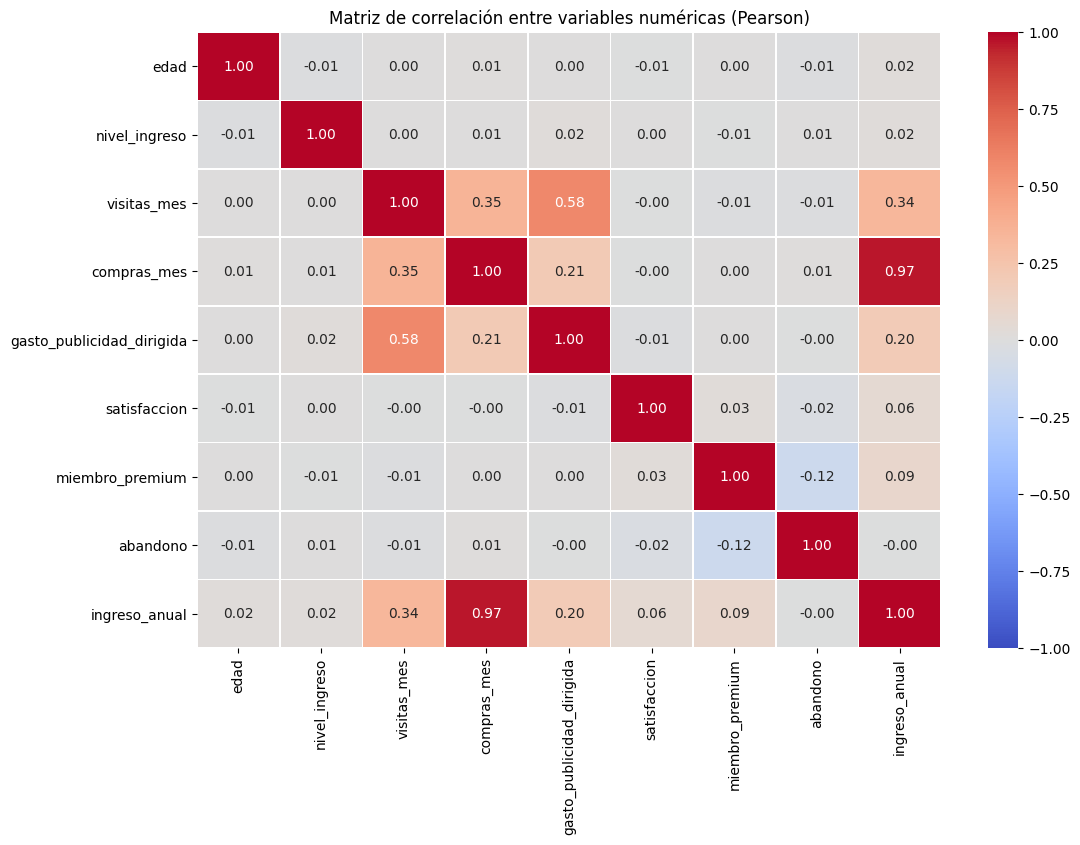

In [10]:

# Visualizar la matriz de correlación para identificar relaciones

# Seleccionar variables numéricas relevantes
columnas_numericas = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'miembro_premium',
    'abandono',
    'ingreso_anual'
]

# Crear dataframe numérico
df_num = df[columnas_numericas]

# Calcular matriz de correlación
corr_matrix = df_num.corr()

# Visualizar heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Matriz de correlación entre variables numéricas (Pearson)')
plt.show()

## Observaciones generales (Heatmap)

- Se observa que la mayoría de las correlaciones entre variables son bajas o cercanas a cero, lo que indica relaciones lineales débiles o inexistentes.
- Se identifica una correlación positiva moderada entre `visitas_mes` y `gasto_publicidad_dirigida` (0.58), lo que sugiere una asociación entre ambas variables.
- También se observa una correlación positiva entre `visitas_mes` y `compras_mes` (0.35), indicando que estas variables tienden a moverse en la misma dirección.
- La variable `edad` no presenta correlaciones relevantes con otras variables, lo que sugiere ausencia de relación lineal significativa.
- Las variables binarias (`miembro_premium` y `abandono`) muestran correlaciones muy bajas con el resto de variables, indicando asociaciones débiles en este contexto.

---

## Observaciones respecto a `ingreso_anual`

- Presenta una correlación positiva muy alta con `compras_mes` (0.97), lo que indica una fuerte asociación lineal entre ambas variables.
- Se observa una correlación positiva moderada con `visitas_mes` (0.34), lo que sugiere que ambas variables tienden a incrementarse conjuntamente.
- Existe una correlación positiva débil con `gasto_publicidad_dirigida` (0.20), indicando una asociación leve.
- La variable `satisfaccion` muestra una correlación muy baja (0.06), lo que sugiere una relación lineal prácticamente inexistente.
- `miembro_premium` presenta una correlación baja (0.09), indicando una asociación débil con el ingreso.
- `abandono` no muestra correlación relevante con `ingreso_anual`, lo que sugiere ausencia de relación lineal significativa.
- `edad` y `nivel_ingreso` presentan correlaciones cercanas a cero (~0.02), indicando que no existe una relación lineal apreciable con el ingreso en este análisis.

---

## Nota metodológica

Este análisis es de carácter exploratorio y correlacional. Las asociaciones observadas no implican relaciones causales, sino únicamente patrones de comportamiento conjunto entre variables. ëste comportamiento se tiene que analizar a detalle


### Scatterplot general


**Evaluación del uso de scatterplot general**

Con base en el análisis de correlación, no es necesario generar un scatterplot general para todas las variables, ya que el heatmap ya proporciona una visión global de las relaciones lineales.

Sin embargo, es recomendable utilizar scatterplots específicos para aquellas variables que presentan correlaciones relevantes, con el fin de analizar la forma de la relación, la dispersión de los datos y la posible presencia de valores atípicos.

En particular, destacan las siguientes relaciones:

- `compras_mes` vs `ingreso_anual`, debido a su alta correlación.
- `visitas_mes` vs `ingreso_anual`, por su correlación moderada.
- `gasto_publicidad_dirigida` vs `ingreso_anual`, aunque su correlación es débil, podría aportar información adicional.

En conclusión, los scatterplots deben utilizarse de forma selectiva como complemento al heatmap, dentro de un enfoque exploratorio y no como una visualización general de todas las variables.

### Scatterplot para pares clave

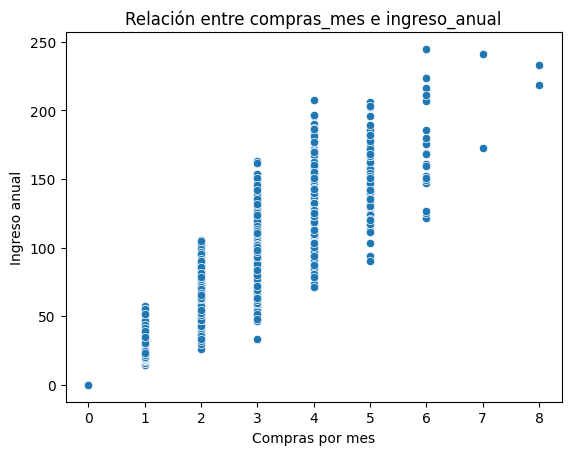

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual')

plt.title('Relación entre compras_mes e ingreso_anual')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')
plt.show()

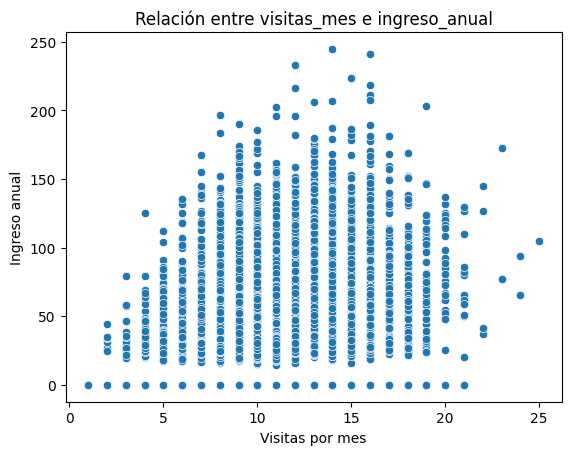

In [12]:
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual')

plt.title('Relación entre visitas_mes e ingreso_anual')
plt.xlabel('Visitas por mes')
plt.ylabel('Ingreso anual')
plt.show()

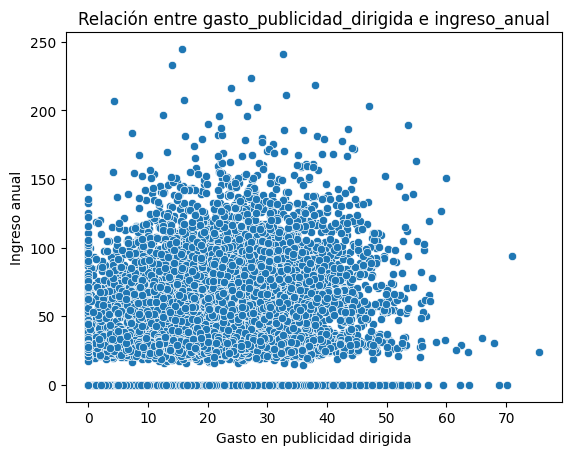

In [13]:
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual')

plt.title('Relación entre gasto_publicidad_dirigida e ingreso_anual')
plt.xlabel('Gasto en publicidad dirigida')
plt.ylabel('Ingreso anual')

plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**
- Dirección: Se observa una relación positiva clara, ya que a medida que aumentan las compras mensuales, el ingreso anual también tiende a incrementarse.
- Dispersión: Baja a moderada, los puntos están relativamente alineados, lo que indica una relación fuerte y consistente.
- Outliers: Se identifican algunos valores altos de ingreso en niveles elevados de compras, pero no parecen extremos ni inconsistentes.
- Posible colinealidad: Alta, debido a la fuerte asociación observada, lo cual es consistente con la alta correlación previamente identificada.

**visitas_mes vs ingreso_anual**
- Dirección: Se observa una relación positiva, aunque menos definida que en el caso anterior.
- Dispersión: Alta, los puntos están ampliamente distribuidos, lo que indica mayor variabilidad en el ingreso para un mismo nivel de visitas.
- Outliers: Se observan algunos valores elevados de ingreso en distintos niveles de visitas, así como varios valores cercanos a cero, lo que sugiere presencia de posibles outliers.
- Posible colinealidad: Baja a moderada, ya que la relación no es tan fuerte ni lineal como en el caso de compras.

**gasto_publicidad_dirigida vs ingreso_anual**
- Dirección: Débilmente positiva / Casi nula.
- Dispersión: Alta, los puntos están ampliamente distribuidos.
- Outliers: Presencia de ingresos máximos (>200) asociados a niveles de gasto moderados.
- Colinealidad: Inexistente. Las variables son estadísticamente independientes para propósitos de modelado multivariado.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [14]:
# Calcular correlación entre variables numericas
target = 'ingreso_anual'
numeric_features = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion']

lista = []

for col in numeric_features:

  pearson_r, pearson_p = stats.pearsonr(df[target], df[col])
  spearman_r, spearman_p = stats.spearmanr(df[target], df[col])

  lista.append({
      'variable': col,
      'pearson_r': pearson_r,
      'spearman_r': spearman_r
  })




corr_num = pd.DataFrame(lista)
corr_num

,variable,pearson_r,spearman_r
0,edad,0.017496,0.016097
1,nivel_ingreso,0.017446,0.025017
2,visitas_mes,0.337147,0.320954
3,compras_mes,0.967149,0.967482
4,gasto_publicidad_dirigida,0.197483,0.184999
5,satisfaccion,0.056171,0.060834


**Observaciones de correlación**

**ingreso_anual vs compras_mes**
- Correlación: Positiva muy alta (Pearson ≈ 0.97, Spearman ≈ 0.97).
- Magnitud: Muy fuerte, lo que indica una asociación lineal y monotónica consistente entre ambas variables.
- Posible colinealidad: Alta, ya que ambas variables muestran un comportamiento muy similar en términos de variación conjunta.

---

**ingreso_anual vs visitas_mes**
- Correlación: Positiva moderada (Pearson ≈ 0.34, Spearman ≈ 0.32).
- Magnitud: Media, lo que sugiere una asociación moderada entre ambas variables.
- Posible colinealidad: Baja a moderada, ya que la relación no es lo suficientemente fuerte como para indicar dependencia elevada.

---

**ingreso_anual vs gasto_publicidad_dirigida**
- Correlación: Positiva débil (Pearson ≈ 0.20, Spearman ≈ 0.18).
- Magnitud: Baja, lo que indica una asociación limitada entre las variables.
- Posible colinealidad: Baja, debido a la débil relación observada.

---

**ingreso_anual vs satisfaccion**
- Correlación: Positiva muy débil (Pearson ≈ 0.06, Spearman ≈ 0.06).
- Magnitud: Muy baja, lo que sugiere prácticamente ausencia de relación lineal o monotónica.
- Posible colinealidad: Nula o insignificante.

---

**ingreso_anual vs edad**
- Correlación: Positiva prácticamente nula (Pearson ≈ 0.02, Spearman ≈ 0.02).
- Magnitud: Muy baja, sin evidencia de asociación relevante.
- Posible colinealidad: Nula.

---

**ingreso_anual vs nivel_ingreso**
- Correlación: Positiva prácticamente nula (Pearson ≈ 0.02, Spearman ≈ 0.03).
- Magnitud: Muy baja, lo que indica ausencia de relación significativa.
- Posible colinealidad: Nula.

### Punto-biserial

In [15]:
# Calcular correlación entre variables binarias y el ingreso anual
binary_features = ['miembro_premium', 'abandono']

lista = []

for col in binary_features:
 pb_r, pb_p =  stats.pointbiserialr(df[col], df[target])
 lista.append({
     'variable': col,
     'point_biserial_r': pb_r
 })

corr_bin = pd.DataFrame(lista)
corr_bin

,variable,point_biserial_r
0,miembro_premium,0.093099
1,abandono,-0.002824


**Observaciones Punto-biserial**

**ingreso_anual vs miembro_premium**
- Relación: Positiva (r ≈ 0.09).
- Magnitud: Baja, lo que indica una asociación débil entre ser miembro premium y el ingreso anual.

---

**ingreso_anual vs abandono**
- Relación: Negativa (r ≈ -0.003).
- Magnitud: Muy baja (prácticamente nula), lo que sugiere ausencia de asociación entre el abandono y el ingreso anual en términos lineales.

### V de Cramér

In [16]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcula V de Cramér para dos variables categóricas (region y tipo de dispositivo."""
    contingency = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    r, k = contingency.shape
    phi2 = chi2 / n
    # Corrección por sesgo (opcional, pero mejora estabilidad)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    v = np.sqrt(phi2corr / denom) if denom > 0 else np.nan
    return v, p

v_region_disp, p_region_disp = cramers_v(df['region'], df['tipo_dispositivo'])
v_region_disp

0.0

In [17]:
# Aplicar V de Cramér en variables relevantes


for col in ['region', 'tipo_dispositivo']:
    v, p = cramers_v(df[col], df['abandono'])
    print(f"{col} vs abandono -> V de Cramér={v:.3f} (p={p:.3g})")

for col in ['region', 'tipo_dispositivo']:
    v, p = cramers_v(df[col], df['miembro_premium'])
    print(f"{col} vs miembro_premium -> V de Cramér={v:.3f} (p={p:.3g})")
   

region vs abandono -> V de Cramér=0.006 (p=0.312)
tipo_dispositivo vs abandono -> V de Cramér=0.000 (p=0.675)
region vs miembro_premium -> V de Cramér=0.000 (p=0.499)
tipo_dispositivo vs miembro_premium -> V de Cramér=0.016 (p=0.054)


**Observaciones V de Cramér**

- Se observa que todas las asociaciones entre variables categóricas son muy débiles o prácticamente nulas, con valores de V de Cramér cercanos a 0.

- La relación entre `region` y `abandono` (V ≈ 0.006) es prácticamente inexistente, lo que indica que no hay asociación relevante entre la ubicación geográfica y el abandono.

- La relación entre `tipo_dispositivo` y `abandono` (V ≈ 0.000) es nula, lo que sugiere ausencia total de asociación entre el tipo de dispositivo y el abandono.

- La relación entre `region` y `miembro_premium` (V ≈ 0.000) también es inexistente, indicando que la pertenencia a premium no está asociada con la región.

- La relación entre `tipo_dispositivo` y `miembro_premium` (V ≈ 0.016) es muy débil, aunque ligeramente mayor que las anteriores, sigue sin representar una asociación significativa.

- En términos de significancia estadística, los valores de p son mayores a 0.05 en todos los casos, lo que refuerza la ausencia de evidencia de asociación estadísticamente significativa.


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las coeficientes de correlación y asociación de la sección 4 fueron correctamente aplicados, además las observaciones realizadas me parecen excelentes, bien hecho!
</div>

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica
3) Interpretación (no causal)
4) No podemos afirmar
5) Implicación de negocio

---

**Hallazgo 1: El motor transaccional (Compras vs. Ingreso anual)**

**Evidencia visual:**  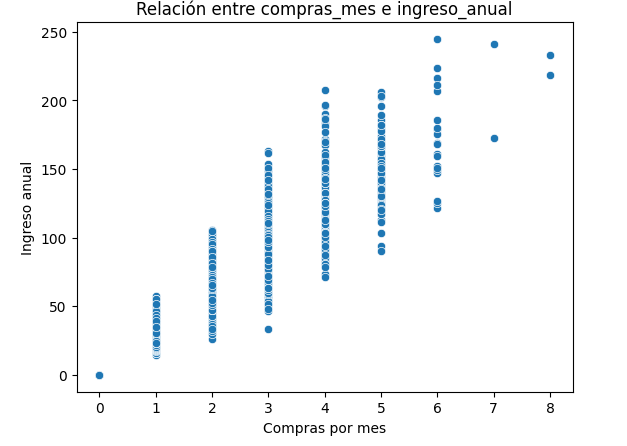

El scatterplot muestra una alineación clara de los puntos en sentido ascendente, con una dispersión baja a moderada.

**Evidencia numérica:**  
Coeficiente de correlación de Pearson alto (r ≈ 0.96).

**Interpretación:**  
Se observa una relación positiva fuerte; los clientes que registran un mayor número de transacciones mensuales tienden a presentar mayores niveles de ingreso anual para la plataforma.

**No podemos afirmar:**  
Que incrementar artificialmente el número de compras causará un aumento en el ingreso anual, ni que el ingreso dependa exclusivamente del volumen de compras.

**Implicación de negocio:**  
Las estrategias de retención pueden enfocarse en fomentar la frecuencia de compra. Programas de lealtad o incentivos a la recurrencia podrían estar asociados con mayores niveles de ingreso.

--------

**Hallazgo 2: Publicidad dirigida y variabilidad del ingreso**

**Evidencia visual:**  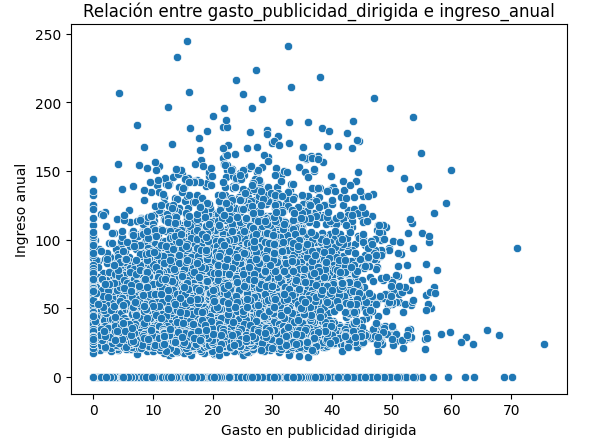

El scatterplot presenta una distribución dispersa tipo "nube", con alta variabilidad y acumulación de valores en niveles bajos de ingreso.

**Evidencia numérica:**  
Correlación de Pearson débil (r < 0.30).

**Interpretación:**  
El gasto en publicidad dirigida muestra una asociación débil con el ingreso anual, lo que sugiere alta variabilidad en los resultados.

**No podemos afirmar:**  
Que la publicidad no sea efectiva o que deba eliminarse, ni que el gasto publicitario sea responsable directo de niveles bajos de ingreso.

**Implicación de negocio:**  
Es recomendable revisar los criterios de segmentación publicitaria. Se sugiere realizar experimentación controlada para optimizar la asignación del presupuesto.

--------

**Hallazgo 3: El factor Premium (Suscripción vs. Ingreso)**

**Evidencia numérica:**  
Correlación punto biserial positiva (r_pb ≈ 0.09 en este análisis).

**Interpretación:**  
La variable miembro_premium presenta una asociación positiva débil con el ingreso anual.

**No podemos afirmar:**  
Que convertirse en usuario premium genere un incremento en el ingreso, ya que la relación observada no implica causalidad.

**Implicación de negocio:**  
El estatus premium puede utilizarse como variable de segmentación para análisis adicionales. Es recomendable explorar qué comportamientos están asociados con la adopción del modelo premium.

--------

**Hallazgo 4: Independencia demográfica (Edad y Región)**

**Evidencia visual:**  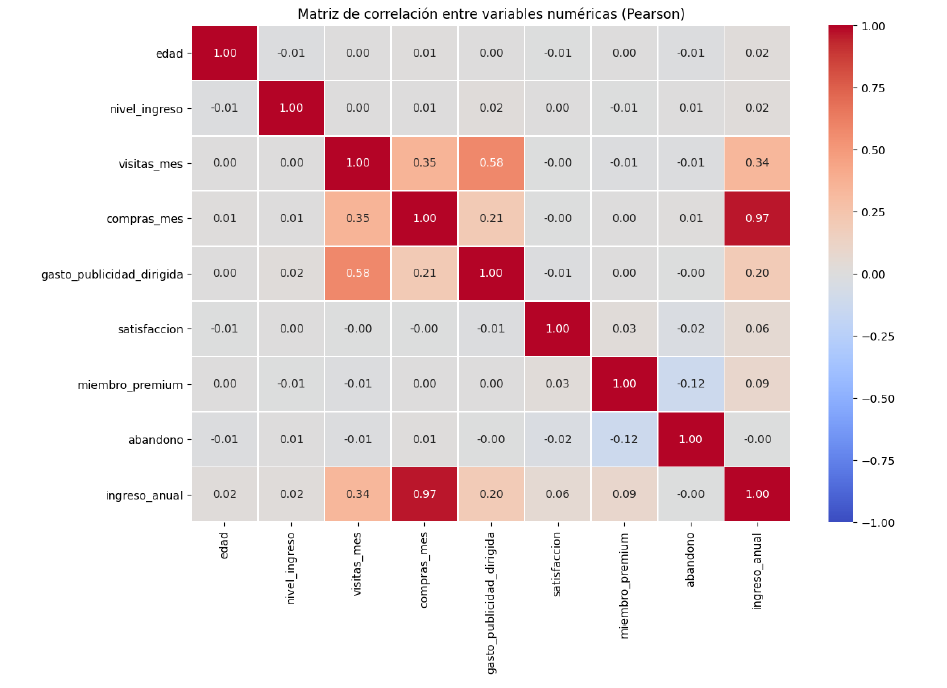

El heatmap muestra valores cercanos a cero en la correlación con edad, y las distribuciones categóricas por región son relativamente equilibradas.

**Evidencia numérica:**  
Coeficientes de correlación cercanos a 0 y valores de V de Cramér muy bajos.

**Interpretación:**  
No se observan asociaciones relevantes entre el ingreso anual y variables demográficas como edad o región.

**No podemos afirmar:**  
Que estas variables no sean relevantes para otros aspectos del comportamiento del cliente, solo que no muestran asociación con el ingreso en este análisis.

**Implicación de negocio:**  
Las estrategias pueden enfocarse más en variables de comportamiento que en segmentaciones demográficas tradicionales.


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
**Naturaleza no causal:**  
Este análisis es de carácter exploratorio y correlacional; las asociaciones identificadas no implican relaciones de causa-efecto.

**Variables omitidas:**  
Existen factores externos no incluidos en el dataset (como condiciones económicas, promociones o comportamiento de la competencia) que podrían influir en el ingreso anual y en las relaciones observadas.


### **Próximos pasos** 

**Segmentación de clientes:**  
Aplicar técnicas de clustering (por ejemplo, K-Means) para identificar grupos de usuarios con comportamientos similares y profundizar en patrones no capturados por la correlación lineal.

**Experimentación controlada:**  
Diseñar pruebas A/B para evaluar estrategias como campañas publicitarias o incentivos de compra, permitiendo analizar su efecto en variables clave bajo un enfoque más cercano a causalidad.

**Análisis adicional:**  
Explorar modelos más avanzados (como regresión o árboles de decisión) para entender mejor la relación entre múltiples variables y el ingreso anual.